# Import Libraries

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

import os
import glob

mne.set_log_level('WARNING')  # keeps output clean

# Load and Preprocess

- Path for **Subject 1 Night 1** 

In [3]:
psg_path  = "sleep-cassette/SC4001E0-PSG.edf"
hyp_path  = "sleep-cassette/SC4001EC-Hypnogram.edf"

- Load the raw PSG signal

In [5]:
raw = mne.io.read_raw_edf(psg_path, preload=True)

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\2426353165.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\2426353165.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\2426353165.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


- Basic Info

In [6]:
print(raw.info)
print("=" * 50)
print("\nChannel names:", raw.ch_names)
print("=" * 50)
print("Sampling frequency:", raw.info['sfreq'], "Hz")
print("=" * 50)
print("Duration:", round(raw.times[-1] / 3600, 2), "hours")

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>

Channel names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 hours


**Important Notes:**

- **Subject:** Female, 33 years old, recorded in 1989.

- **7 channels:** but we care only about `EEG Fpz-Ez` (The paper uses this one channel only).

- **100 Hz:** means 100 data points per second.

- **22 hours of continous recording:** that's a full day/night at home with the cassette recorder.

- **Lowpass 50Hz:** high frequency noise already filtered out by the hardware.

**Why Fpz-Cz specifically?**
- Because it capures the brain's electrical activity well enough to **distinguish sleep stages**.

|  Sleep Stage   |   What the EEG looks like    |
|----------------|------------------------------|
| Wake (W) | Fast, low-amplitude waves (busy, alert brain) |
| N1 |  Slower waves, theta activity (4–8 Hz) |
| N2 | Sleep spindles (bursts of 12–15 Hz) + K-complexes |
| N3 | Slow, large delta waves (0.5–4 Hz). Deep sleep |
| REM | Fast waves again, similar to wake but you're dreaming.

# Load the hypnogram (annotations)

In [8]:
annotations = mne.read_annotations(hyp_path)

print("Number of annotations:", len(annotations))

Number of annotations: 154


In [9]:
print("First 10 annotations:")

for ann in annotations[:10]:
    print(f"  - Onset: {ann['onset']}s, Duration: {ann['duration']}s, Description: {ann['description']}")

First 10 annotations:
  - Onset: 0.0s, Duration: 30630.0s, Description: Sleep stage W
  - Onset: 30630.0s, Duration: 120.0s, Description: Sleep stage 1
  - Onset: 30750.0s, Duration: 390.0s, Description: Sleep stage 2
  - Onset: 31140.0s, Duration: 30.0s, Description: Sleep stage 3
  - Onset: 31170.0s, Duration: 30.0s, Description: Sleep stage 2
  - Onset: 31200.0s, Duration: 150.0s, Description: Sleep stage 3
  - Onset: 31350.0s, Duration: 30.0s, Description: Sleep stage 4
  - Onset: 31380.0s, Duration: 60.0s, Description: Sleep stage 3
  - Onset: 31440.0s, Duration: 60.0s, Description: Sleep stage 4
  - Onset: 31500.0s, Duration: 30.0s, Description: Sleep stage 3


**Important Notes:**

- The first annotation is crucial because it has a huge amount of time.
    - This means that this subject was **awake for 8.5 hours** before falling asleep.
    - That's because the cassette recorder running all day before bedtime.
    - And **Wake (W)** periods are much longer than sleep stages, so researchers usually trim Wake data to only **30 minutes before and after sleep** to reduce severe class imbalance.

- Sleep annotations are organized into **30-second epochs**, which means that each sleep stage label corresponds to one or more consecutive 30-second EEG windows.

#### Map labels to numbers for plotting

In [10]:
stage_map = {
    'Sleep stage W':  0,
    'Sleep stage 1':  1,
    'Sleep stage 2':  2,
    'Sleep stage 3':  3,
    'Sleep stage 4':  3,  # merge with N3
    'Sleep stage R':  4,
    'Sleep stage ?': -1,
    'Movement time': -1,
}

#### Build a timeline of stages (one label per 30s)

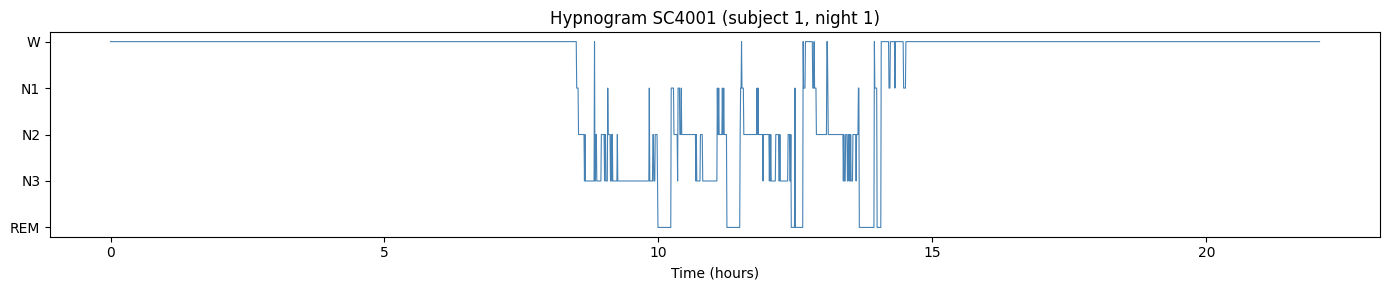


Epoch counts per stage:
  W: 1996 epochs  (998.0 min)
  N1: 58 epochs  (29.0 min)
  N2: 250 epochs  (125.0 min)
  N3: 220 epochs  (110.0 min)
  REM: 125 epochs  (62.5 min)


In [12]:
epoch_duration = 30
total_epochs = int(raw.times[-1] / epoch_duration)
labels = np.full(total_epochs, -1)  # fill with -1 (unknown)

for ann in annotations:
    onset_epoch  = int(ann['onset'] / epoch_duration)
    n_epochs     = int(ann['duration'] / epoch_duration)
    stage        = stage_map.get(ann['description'], -1)
    labels[onset_epoch : onset_epoch + n_epochs] = stage

# Plot
fig, ax = plt.subplots(figsize=(14, 3))
time_hours = np.arange(total_epochs) * epoch_duration / 3600

ax.plot(time_hours, labels, color='steelblue', linewidth=0.8)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['W', 'N1', 'N2', 'N3', 'REM'])
ax.set_xlabel("Time (hours)")
ax.set_title("Hypnogram SC4001 (subject 1, night 1)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Label distribution
unique, counts = np.unique(labels[labels >= 0], return_counts=True)
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("\nEpoch counts per stage:")
for u, c in zip(unique, counts):
    print(f"  {stage_names[u]}: {c} epochs  ({c*30/60:.1f} min)")

**Important Notes from the hypnogram:**

- The **flat line** from hour 0 to nearly **hour 8.5** is that long Wake period.

- Sleep starts around **hour 8.5** and ends around **hour 15**.  About 6.5 hours of actual sleep.

- You can see the **cycling pattern**. The brain goes deep (N2 to N3) then comes back up to REM, repeating every ~90 minutes. This is normal healthy sleep architecture.

**From Epoch Counts:**
- There is **class imbalance**.
- And if we train as this as is, the model will just learn to predict Wake (W) all the time.


#### Extract the Fpz-Cz channel only

Total samples: 7950000
Total epochs: 2650


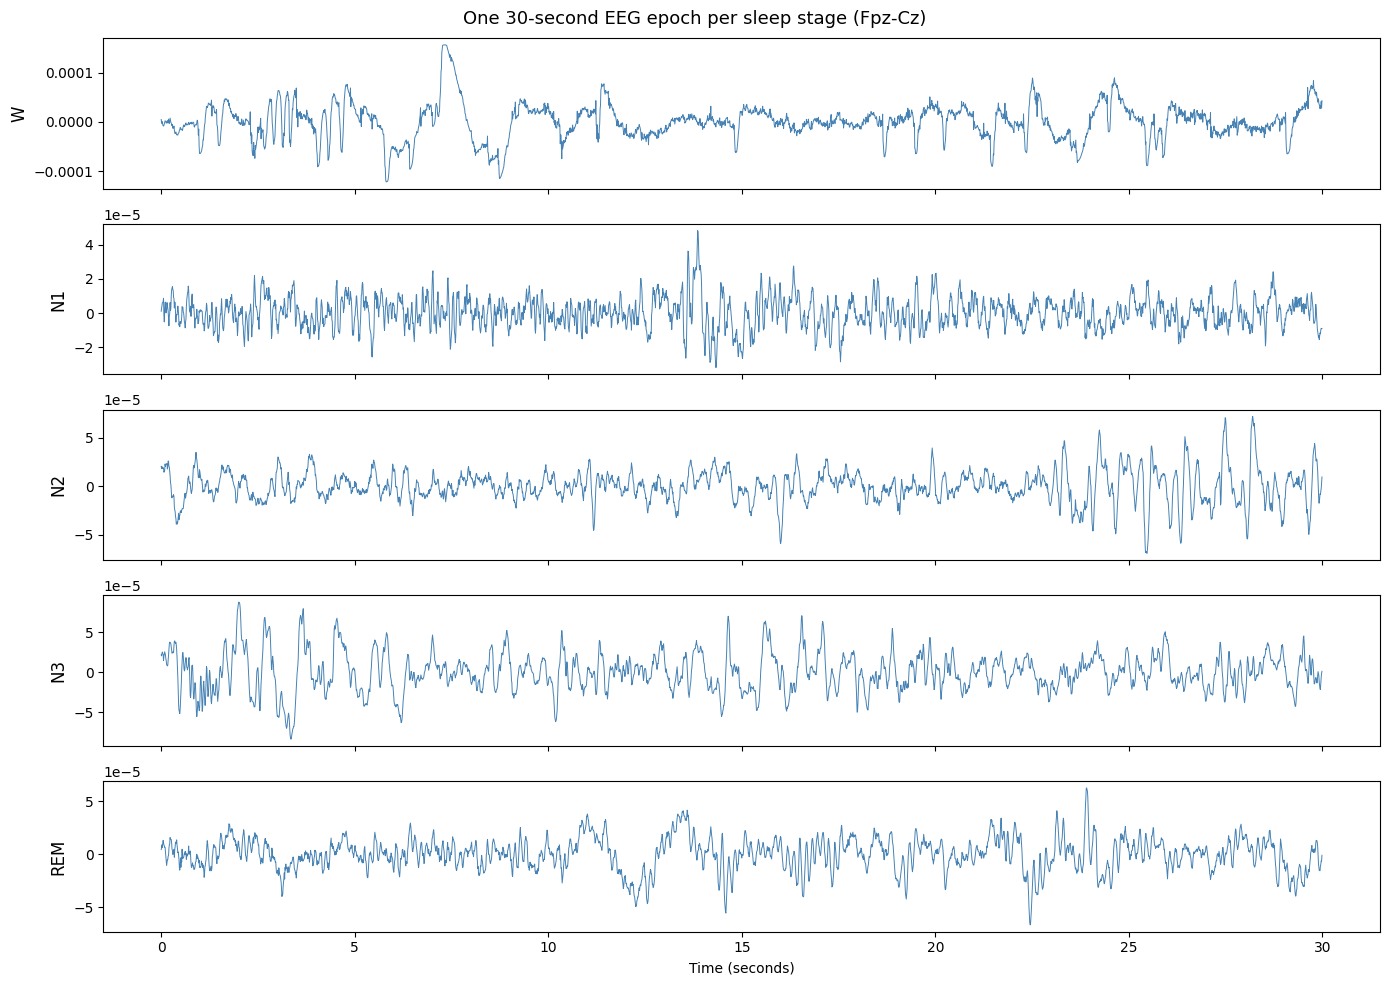

W: min=-0.000122, max=0.000157
N1: min=-0.000032, max=0.000048
N2: min=-0.000069, max=0.000072
N3: min=-0.000084, max=0.000088
REM: min=-0.000066, max=0.000062


In [ ]:
raw_fpz = raw.copy().pick(['EEG Fpz-Cz'])
data, times = raw_fpz[:]   # shape: (1, total_samples)
data = data[0]             # flatten to 1D

print("Total samples:", len(data))
print("Total epochs:", len(data) // 3000)

# Pick one epoch from each stage to visualize
# Find first epoch of each stage
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    start_sample = epoch_idx * 3000
    epoch_data = data[start_sample : start_sample + 3000]
    t = np.arange(3000) / 100

    axes[stage_id].plot(t, epoch_data, linewidth=0.7, color='steelblue')
    axes[stage_id].set_ylabel(stage_names[stage_id], fontsize=12)
    # Let matplotlib auto-scale each subplot individually
    axes[stage_id].autoscale(axis='y')

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("One 30-second EEG epoch per sleep stage (Fpz-Cz)", fontsize=13)
plt.tight_layout()
plt.show()

# Also print the actual value range so we know the unit
for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    epoch_data = data[epoch_idx*3000 : epoch_idx*3000 + 3000]
    print(f"{stage_names[stage_id]}: min={epoch_data.min():.6f}, max={epoch_data.max():.6f}")

**Notes:**

- **W (Wake):** 
    - notice the scale is 1e-4, much larger amplitude than the others. Fast, irregular, high-energy signal. 
    - The brain is very active.

- **N1:** 
    - Scale drops to 1e-5. Slower, smaller waves. 
    - The brain is starting to quiet down.

- **N2:** 
    - Similar scale to N1 but you can see bursts of faster oscillations. Those are sleep spindles (12–15 Hz bursts). 
    - The CNN will learn to detect these.

- **N3:**
    - large, slow, rolling waves. These are delta waves (0.5–4 Hz). Notice the waves are wider and taller.
    - Classic deep sleep.

- **REM:**
    - Looks similar to N1/N2 but with more irregular, mixed-frequency activity. 
    - Hardest stage to distinguish visually.

**Notes:**

- The data is in **volts**.
- The paper and the standard practice work in **microvolts**, so we convert it.

In [15]:
# Convert to microvolts (multiply by 1e6)
data_uv = data * 1e6

# Verify the range now looks normal for EEG (should be roughly ±100 uV)
for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    epoch_data = data_uv[epoch_idx*3000 : epoch_idx*3000 + 3000]
    print(f"{stage_names[stage_id]}: min={epoch_data.min():.1f} uV, max={epoch_data.max():.1f} uV")

W: min=-121.6 uV, max=156.6 uV
N1: min=-31.9 uV, max=48.2 uV
N2: min=-69.2 uV, max=72.3 uV
N3: min=-83.9 uV, max=87.9 uV
REM: min=-66.4 uV, max=62.4 uV


`load_subject`: is a function that will do everything we've done so far in one call.                                                   
    1. Load the PSG                                       
    2. Load the hypnogram                                       
    3. Convert to µV                                              
    4. Return clean epochs + labels.

In [ ]:
def load_subject(psg_path, hyp_path):
    
    stage_map = {
        'Sleep stage W':  0,
        'Sleep stage 1':  1,
        'Sleep stage 2':  2,
        'Sleep stage 3':  3,
        'Sleep stage 4':  3,  # merge N3+N4
        'Sleep stage R':  4,
        'Sleep stage ?': -1,
        'Movement time': -1,
    }

    # Load raw signal → pick Fpz-Cz only → convert to uV
    raw = mne.io.read_raw_edf(psg_path, preload=True)
    raw.pick(['EEG Fpz-Cz'])
    data = raw.get_data()[0] * 1e6          # shape: (total_samples,)

    # Build label array (one label per 30s epoch)
    annotations = mne.read_annotations(hyp_path)
    total_epochs = len(data) // 3000
    labels = np.full(total_epochs, -1)

    for ann in annotations:
        onset_epoch = int(ann['onset'] / 30)
        n_epochs    = int(ann['duration'] / 30)
        stage       = stage_map.get(ann['description'], -1)
        labels[onset_epoch : onset_epoch + n_epochs] = stage

    # Trim Wake: keep only 30 min (60 epochs) before and after sleep
    sleep_epochs = np.where(labels > 0)[0]
    sleep_start  = sleep_epochs[0]
    sleep_end    = sleep_epochs[-1]

    trim_start = max(0, sleep_start - 60)
    trim_end   = min(total_epochs, sleep_end + 60)

    labels = labels[trim_start : trim_end]
    data   = data[trim_start * 3000 : trim_end * 3000]

    # Slice into epochs of 3000 samples
    n_epochs_trimmed = len(labels)
    epochs = data[:n_epochs_trimmed * 3000].reshape(n_epochs_trimmed, 3000)

    # Remove unknown/movement epochs
    valid = labels >= 0
    epochs = epochs[valid]
    labels = labels[valid]

    return epochs, labels


# Test it on subject 1 
epochs, labels = load_subject(
    "sleep-cassette/SC4001E0-PSG.edf",
    "sleep-cassette/SC4001EC-Hypnogram.edf"
)

stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("Epochs shape:", epochs.shape)
print("Labels shape:", labels.shape)
print("\nEpoch counts after trimming:")
for i, name in enumerate(stage_names):
    count = np.sum(labels == i)
    print(f"  {name}: {count} epochs  ({count*30/60:.1f} min)")

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Epochs shape: (840, 3000)
Labels shape: (840,)

Epoch counts after trimming:
  W: 187 epochs  (93.5 min)
  N1: 58 epochs  (29.0 min)
  N2: 250 epochs  (125.0 min)
  N3: 220 epochs  (110.0 min)
  REM: 125 epochs  (62.5 min)


**Important Notes:**
- W dropped from **1996 to 187 epochs** (trimmed to ~30 min around sleep)
- All sleep stages are intact - N1, N2, N3, REM unchanged 
- Total: **840 clean epochs** ready for training

- The imbalance is still there (W dominates) but it's much more manageable now. 

- The paper handles the rest through oversampling during training. 

In [ ]:
# Find all PSG files and pair them with their hypnograms
psg_files = sorted(glob.glob("sleep-cassette/SC*E0-PSG.edf"))

print(f"Found {len(psg_files)} PSG files:")
for f in psg_files:
    print(" ", f)

Found 67 PSG files:
  sleep-cassette\SC4001E0-PSG.edf
  sleep-cassette\SC4002E0-PSG.edf
  sleep-cassette\SC4011E0-PSG.edf
  sleep-cassette\SC4012E0-PSG.edf
  sleep-cassette\SC4021E0-PSG.edf
  sleep-cassette\SC4022E0-PSG.edf
  sleep-cassette\SC4031E0-PSG.edf
  sleep-cassette\SC4032E0-PSG.edf
  sleep-cassette\SC4041E0-PSG.edf
  sleep-cassette\SC4042E0-PSG.edf
  sleep-cassette\SC4051E0-PSG.edf
  sleep-cassette\SC4052E0-PSG.edf
  sleep-cassette\SC4061E0-PSG.edf
  sleep-cassette\SC4062E0-PSG.edf
  sleep-cassette\SC4071E0-PSG.edf
  sleep-cassette\SC4072E0-PSG.edf
  sleep-cassette\SC4081E0-PSG.edf
  sleep-cassette\SC4082E0-PSG.edf
  sleep-cassette\SC4091E0-PSG.edf
  sleep-cassette\SC4092E0-PSG.edf
  sleep-cassette\SC4101E0-PSG.edf
  sleep-cassette\SC4102E0-PSG.edf
  sleep-cassette\SC4111E0-PSG.edf
  sleep-cassette\SC4112E0-PSG.edf
  sleep-cassette\SC4121E0-PSG.edf
  sleep-cassette\SC4122E0-PSG.edf
  sleep-cassette\SC4131E0-PSG.edf
  sleep-cassette\SC4141E0-PSG.edf
  sleep-cassette\SC4142E0-PS

- That's the full Sleep Cassette dataset. 
- The paper uses **only the first 20 subjects** (SC40 series, subjects 01–20). So, I will filter to those.

In [19]:
# The SC dataset subject numbers are: 01,02,11,12,21,22,...,91,92,101,102...
# The paper uses the first 20 recordings (first 20 PSG files we have)
# Simplest approach: just take the first 20 from the sorted list

psg_files_20 = sorted(glob.glob("sleep-cassette/SC*E0-PSG.edf"))[:20]

print(f"Using {len(psg_files_20)} subjects:")
for f in psg_files_20:
    print(" ", f)

Using 20 subjects:
  sleep-cassette\SC4001E0-PSG.edf
  sleep-cassette\SC4002E0-PSG.edf
  sleep-cassette\SC4011E0-PSG.edf
  sleep-cassette\SC4012E0-PSG.edf
  sleep-cassette\SC4021E0-PSG.edf
  sleep-cassette\SC4022E0-PSG.edf
  sleep-cassette\SC4031E0-PSG.edf
  sleep-cassette\SC4032E0-PSG.edf
  sleep-cassette\SC4041E0-PSG.edf
  sleep-cassette\SC4042E0-PSG.edf
  sleep-cassette\SC4051E0-PSG.edf
  sleep-cassette\SC4052E0-PSG.edf
  sleep-cassette\SC4061E0-PSG.edf
  sleep-cassette\SC4062E0-PSG.edf
  sleep-cassette\SC4071E0-PSG.edf
  sleep-cassette\SC4072E0-PSG.edf
  sleep-cassette\SC4081E0-PSG.edf
  sleep-cassette\SC4082E0-PSG.edf
  sleep-cassette\SC4091E0-PSG.edf
  sleep-cassette\SC4092E0-PSG.edf


#### Process each subject, and save everything to disk.

In [20]:
os.makedirs("processed", exist_ok=True)

for psg_path in psg_files_20:
    # Build the matching hypnogram path
    basename = os.path.basename(psg_path)          # e.g. SC4001E0-PSG.edf
    subject_id = basename[:7]                       # e.g. SC4001E
    hyp_candidates = glob.glob(f"sleep-cassette/{subject_id}*Hypnogram.edf")
    
    if len(hyp_candidates) == 0:
        print(f"  WARNING: no hypnogram found for {subject_id}, skipping")
        continue
    
    hyp_path = hyp_candidates[0]
    save_path = f"processed/{subject_id}.npz"
    
    # Skip if already processed
    if os.path.exists(save_path):
        print(f"  Already done: {subject_id}")
        continue

    print(f"Processing {subject_id} ...", end=" ")
    epochs, labels = load_subject(psg_path, hyp_path)
    np.savez(save_path, epochs=epochs, labels=labels)
    print(f"saved → {epochs.shape[0]} epochs")

print("\nAll done!")

Processing SC4001E ... 

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


saved → 840 epochs
Processing SC4002E ... 

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


saved → 1126 epochs
Processing SC4011E ... 

...

saved → 1053 epochs
Processing SC4091E ... 

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


saved → 1131 epochs
Processing SC4092E ... 

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\3967001818.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


saved → 1103 epochs

All done!


In [21]:
# Load all processed files and summarize
all_files = sorted(glob.glob("processed/*.npz"))

total_epochs = 0
total_per_stage = np.zeros(5, dtype=int)
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']

print(f"{'Subject':<12} {'Total':>6}  {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5}")
print("-" * 50)

for f in all_files:
    data = np.load(f)
    labels = data['labels']
    subject = os.path.basename(f).replace('.npz', '')
    counts = [np.sum(labels == i) for i in range(5)]
    total_per_stage += counts
    total_epochs += len(labels)
    print(f"{subject:<12} {len(labels):>6}  {counts[0]:>5} {counts[1]:>5} {counts[2]:>5} {counts[3]:>5} {counts[4]:>5}")

print("-" * 50)
print(f"{'TOTAL':<12} {total_epochs:>6}  {total_per_stage[0]:>5} {total_per_stage[1]:>5} {total_per_stage[2]:>5} {total_per_stage[3]:>5} {total_per_stage[4]:>5}")

Subject       Total      W    N1    N2    N3   REM
--------------------------------------------------
SC4001E         840    187    58   250   220   125
SC4002E        1126    182    59   373   297   215
SC4011E        1102    156   109   562   105   170
SC4012E        1185    161    92   660    96   176
SC4021E        1024    127    94   545    95   163
SC4022E        1008    124   184   402   119   179
SC4031E         951    139    61   485    57   209
SC4032E         910    135    45   400   131   199
SC4041E        1234    199   166   620    53   196
SC4042E        1199    184   137   514    94   270
SC4051E         671    207    44   217   135    68
SC4052E        1245    221   114   616   114   180
SC4061E         842    141    56   407   136   102
SC4062E        1015    192    90   417   129   187
SC4071E         975    123    89   403   162   198
SC4072E        1272    406    84   392   222   168
SC4081E        1133    322    68   262   350   131
SC4082E        1053    143    3

**Important Notes:**

- **N1 is the hardest problem** 
    - only 1,689 epochs out of 21,019 total (8%). 
    - Some subjects have very few: SC4091E has only 19 N1 epochs. 
    - The model will struggle most with this class.

- **N2 dominates sleep** 
    - 8,927 epochs (42%). This is normal. 
    - N2 is the most common sleep stage in healthy adults.

- **W is well controlled** 
    - 3,636 total, averaging ~180 per subject. 
    - The trimming worked well. Only SC4072E (406) and SC4081E (322) are a bit high. 
    - Those subjects had longer wake periods around sleep.



**The dataset is ready.**                                    
- 21,019 clean epochs across 20 subjects, all saved as `.npz` files

# Train/Test split

In [22]:
# Load all processed subjects
all_files = sorted(glob.glob("processed/*.npz"))

def load_all_subjects(files):
    subjects = []
    for f in files:
        data = np.load(f)
        subjects.append({
            'name'  : os.path.basename(f).replace('.npz', ''),
            'epochs': data['epochs'],   # shape: (n_epochs, 3000)
            'labels': data['labels']    # shape: (n_epochs,)
        })
    return subjects

subjects = load_all_subjects(all_files)

# Split: subject 0 = test, rest = train
test_subject  = subjects[0]
train_subjects = subjects[1:]

# Concatenate all training subjects into one array
X_train = np.concatenate([s['epochs'] for s in train_subjects], axis=0)
y_train = np.concatenate([s['labels'] for s in train_subjects], axis=0)

# Test is one subject
X_test = test_subject['epochs']
y_test = test_subject['labels']

print(f"Test subject : {test_subject['name']}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")
print()
print(f"Train subjects: {len(train_subjects)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Test subject : SC4001E
X_test  shape: (840, 3000)
y_test  shape: (840,)

Train subjects: 19
X_train shape: (20179, 3000)
y_train shape: (20179,)


**The approach is leave-one-subject-out**

- **Test:** all files belonging to subject X  
- **Train:** all files from the remaining 19 subjects

# Oversampling

The paper does **oversampling** on the training set to fix the class imbalance. 

We need to duplicate minority class epochs so all 5 stages have equal count.

In [23]:
from collections import Counter

# See imbalance before
print("Before oversampling:")
for i, name in enumerate(stage_names):
    print(f"  {name}: {np.sum(y_train == i)}")

# Find the majority class count
counts = Counter(y_train)
max_count = max(counts.values())

# Oversample each class to match the majority
X_resampled = [X_train]
y_resampled = [y_train]

for stage in range(5):
    idx = np.where(y_train == stage)[0]
    n_needed = max_count - len(idx)
    if n_needed > 0:
        extra_idx = np.random.choice(idx, size=n_needed, replace=True)
        X_resampled.append(X_train[extra_idx])
        y_resampled.append(y_train[extra_idx])

X_train_bal = np.concatenate(X_resampled, axis=0)
y_train_bal = np.concatenate(y_resampled, axis=0)

# Shuffle
shuffle_idx = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print("\nAfter oversampling:")
for i, name in enumerate(stage_names):
    print(f"  {name}: {np.sum(y_train_bal == i)}")
print(f"\nTotal training epochs: {len(X_train_bal)}")

Before oversampling:
  W: 3449
  N1: 1631
  N2: 8677
  N3: 2854
  REM: 3568

After oversampling:
  W: 8677
  N1: 8677
  N2: 8677
  N3: 8677
  REM: 8677

Total training epochs: 43385


In [24]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.5.1
GPU available: False


# Build the CNN Model

#### Pre-training

In [26]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, pool_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                      stride=stride, padding=kernel_size//2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.block(x)


class TwoStreamCNN(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()

        # CNN small (high frequency patterns)
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)   # force output to (128, 1)
        )

        # CNN large (low frequency / wave shape patterns)
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)   # force output to (128, 1)
        )

        # After concat: 128 + 128 = 256 features
        self.classifier = nn.Sequential(
            nn.Flatten(),             # (batch, 256)
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        small    = self.cnn_small(x)           # (batch, 128, 1)
        large    = self.cnn_large(x)           # (batch, 128, 1)
        combined = torch.cat([small, large], dim=1)  # (batch, 256, 1)
        return self.classifier(combined)       # (batch, 5)


# Test with a dummy batch
model = TwoStreamCNN()
dummy = torch.zeros(32, 1, 3000)
out   = model(dummy)
print("Model output shape:", out.shape)   # should be (32, 5)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([32, 5])

Total parameters: 519,941


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Prepare data for PyTorch 
# Add channel dimension: (n_epochs, 3000) → (n_epochs, 1, 3000)
X_train_tensor = torch.FloatTensor(X_train_bal).unsqueeze(1)
y_train_tensor = torch.LongTensor(y_train_bal)

X_test_tensor  = torch.FloatTensor(X_test).unsqueeze(1)
y_test_tensor  = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Training setup 
model     = TwoStreamCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Pre-training loop 
n_epochs = 30  # start with 30, paper uses 100 (we can increase later)

print(f"Training on {len(X_train_tensor):,} epochs | batch size: 128\n")

for epoch in range(1, n_epochs + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    acc = 100 * correct / total

    # Evaluate on test every 5 epochs
    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            test_out  = model(X_test_tensor)
            test_acc  = 100 * (test_out.argmax(1) == y_test_tensor).sum().item() / len(y_test_tensor)
        print(f"Epoch {epoch:3d}/{n_epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {acc:.1f}% | Test Acc: {test_acc:.1f}%")
    else:
        print(f"Epoch {epoch:3d}/{n_epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {acc:.1f}%")

print("\nPre-training done!")

Training on 43,385 epochs | batch size: 128

Epoch   1/30 | Loss: 1.4045 | Train Acc: 44.2%
Epoch   2/30 | Loss: 0.9614 | Train Acc: 59.4%
Epoch   3/30 | Loss: 0.8104 | Train Acc: 65.6%
Epoch   4/30 | Loss: 0.7255 | Train Acc: 69.1%
Epoch   5/30 | Loss: 0.6825 | Train Acc: 71.5% | Test Acc: 72.9%
Epoch   6/30 | Loss: 0.6477 | Train Acc: 73.2%
Epoch   7/30 | Loss: 0.6224 | Train Acc: 74.6%
Epoch   8/30 | Loss: 0.6050 | Train Acc: 75.4%
Epoch   9/30 | Loss: 0.5905 | Train Acc: 75.9%
Epoch  10/30 | Loss: 0.5852 | Train Acc: 76.3% | Test Acc: 76.9%
Epoch  11/30 | Loss: 0.5701 | Train Acc: 76.8%
Epoch  12/30 | Loss: 0.5623 | Train Acc: 77.2%
Epoch  13/30 | Loss: 0.5586 | Train Acc: 77.6%
Epoch  14/30 | Loss: 0.5538 | Train Acc: 77.9%
Epoch  15/30 | Loss: 0.5428 | Train Acc: 78.2% | Test Acc: 80.1%
Epoch  16/30 | Loss: 0.5338 | Train Acc: 78.5%
Epoch  17/30 | Loss: 0.5247 | Train Acc: 79.1%
Epoch  18/30 | Loss: 0.5243 | Train Acc: 79.1%
Epoch  19/30 | Loss: 0.5168 | Train Acc: 79.4%
Epoch  2

**Important Notes:**

- Loss is steadily dropping. The model is learning
- Train and test accuracy are close. No overfitting
- Jump from 72.9% to 84.2% test accuracy in 30 epochs. Strong learning curve

CNN weights saved.

Test Accuracy : 84.2%
Macro F1      : 76.3%

              precision    recall  f1-score   support

           W       0.99      0.81      0.89       187
          N1       0.45      0.29      0.35        58
          N2       0.96      0.80      0.87       250
          N3       0.90      0.97      0.93       220
         REM       0.61      1.00      0.76       125

    accuracy                           0.84       840
   macro avg       0.78      0.77      0.76       840
weighted avg       0.87      0.84      0.84       840



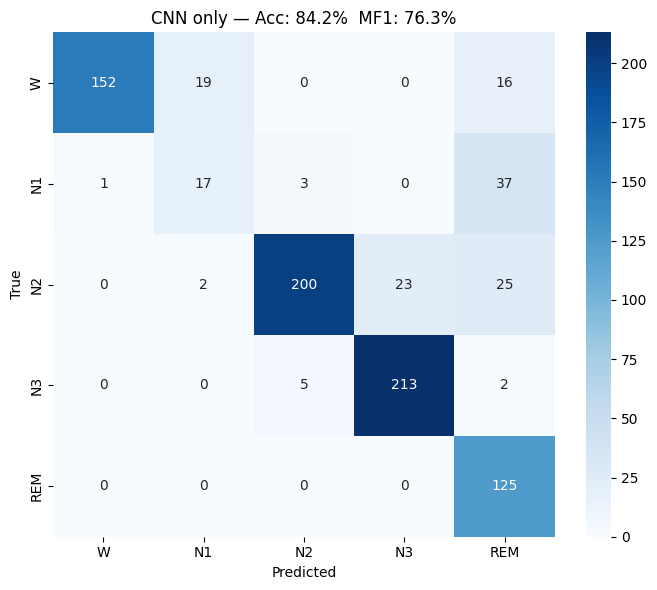

In [28]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Save CNN weights
torch.save(model.state_dict(), "cnn_pretrained.pth")
print("CNN weights saved.\n")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_out  = model(X_test_tensor)
    y_pred    = test_out.argmax(1).numpy()
    y_true    = y_test_tensor.numpy()

# Metrics
acc = 100 * (y_pred == y_true).mean()
mf1 = f1_score(y_true, y_pred, average='macro') * 100

print(f"Test Accuracy : {acc:.1f}%")
print(f"Macro F1      : {mf1:.1f}%")
print()
print(classification_report(y_true, y_pred, target_names=stage_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"CNN only — Acc: {acc:.1f}%  MF1: {mf1:.1f}%")
plt.tight_layout()
plt.show()

**What the CNN does well:**

- **N3: 97% recall.** almost perfect, slow delta waves are very distinctive.
- **REM: 100% recall.** catches every single REM epoch.
- **W: 81% recall.** good, misses some as N1 or REM.

**Where the CNN struggles:**

- **N1: only 29% recall.** 37 out of 58 N1 epochs get misclassified as REM. This is the hardest stage and a known problem in the field. N1 looks similar to REM on a single epoch
- **N2: 80% recall.** 23 epochs confused with N3, 25 with REM

#### Fine-Tuning with BiLSTM

In [ ]:
class DeepSleepNet(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()

        # --- Same two CNN streams as before ---
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        # --- BiLSTM: takes sequence of CNN features ---
        # input size = 256 (128 small + 128 large)
        self.bilstm1 = nn.LSTM(input_size=256, hidden_size=512,
                               batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(input_size=1024, hidden_size=512,
                               batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(0.5)

        # Shortcut: projects CNN features (256) to match BiLSTM output (1024)
        self.shortcut = nn.Linear(256, 1024)

        # Final classifier
        self.classifier = nn.Linear(1024, n_classes)

    def extract_cnn_features(self, x):
        """Extract CNN features for a single epoch. x: (batch, 1, 3000)"""
        small    = self.cnn_small(x).squeeze(-1)   # (batch, 128)
        large    = self.cnn_large(x).squeeze(-1)   # (batch, 128)
        combined = torch.cat([small, large], dim=1) # (batch, 256)
        return combined

    def forward(self, x):
        """
        x shape: (batch, seq_len, 3000)
        seq_len = number of consecutive epochs fed as a sequence
        """
        batch, seq_len, signal_len = x.shape

        # Extract CNN features for every epoch in the sequence
        cnn_out = []
        for t in range(seq_len):
            feat = self.extract_cnn_features(x[:, t, :].unsqueeze(1))  # (batch, 256)
            cnn_out.append(feat)
        cnn_out = torch.stack(cnn_out, dim=1)   # (batch, seq_len, 256)

        # BiLSTM layers
        lstm_out, _ = self.bilstm1(cnn_out)              # (batch, seq_len, 1024)
        lstm_out     = self.dropout(lstm_out)
        lstm_out, _  = self.bilstm2(lstm_out)            # (batch, seq_len, 1024)
        lstm_out      = self.dropout(lstm_out)

        # Residual connection: add projected CNN features
        shortcut = self.shortcut(cnn_out)                # (batch, seq_len, 1024)
        out       = lstm_out + shortcut                  # (batch, seq_len, 1024)

        # Classify every epoch in the sequence
        out = self.classifier(out)                       # (batch, seq_len, 5)
        return out


# Test with a dummy sequence of 25 epochs
full_model = DeepSleepNet()
dummy_seq  = torch.zeros(4, 25, 3000)   # 4 batches, 25 epochs each
out        = full_model(dummy_seq)
print("Full model output shape:", out.shape)   # should be (4, 25, 5)
print(f"Total parameters: {sum(p.numel() for p in full_model.parameters()):,}")

Full model output shape: torch.Size([4, 25, 5])
Total parameters: 10,240,517


In [ ]:
# --- Load pretrained CNN weights into the full model ---
pretrained = torch.load("cnn_pretrained.pth")

# Only copy the CNN weights (small and large streams)
full_model_dict = full_model.state_dict()
cnn_weights = {k: v for k, v in pretrained.items() 
               if k.startswith('cnn_small') or k.startswith('cnn_large')}

full_model_dict.update(cnn_weights)
full_model.load_state_dict(full_model_dict)
print(f"Loaded {len(cnn_weights)} CNN weight tensors from pretrained model\n")

# --- Prepare sequential data ---
# The BiLSTM needs sequences of consecutive epochs per subject
SEQ_LEN = 25  # number of consecutive epochs per sequence

def make_sequences(epochs, labels, seq_len=25):
    """Slice subject data into consecutive sequences of seq_len epochs"""
    X_seqs, y_seqs = [], []
    n = len(labels)
    for start in range(0, n - seq_len + 1, seq_len):
        X_seqs.append(epochs[start : start + seq_len])
        y_seqs.append(labels[start : start + seq_len])
    return np.array(X_seqs), np.array(y_seqs)

# Build sequential training set (one sequence per subject, in order)
X_seq_list, y_seq_list = [], []
for s in train_subjects:
    X_s, y_s = make_sequences(s['epochs'], s['labels'], SEQ_LEN)
    X_seq_list.append(X_s)
    y_seq_list.append(y_s)

X_train_seq = np.concatenate(X_seq_list, axis=0)  # (n_seqs, 25, 3000)
y_train_seq = np.concatenate(y_seq_list, axis=0)  # (n_seqs, 25)

print(f"Training sequences : {X_train_seq.shape}")
print(f"Label sequences    : {y_train_seq.shape}")

# Test sequences
X_test_seq, y_test_seq = make_sequences(X_test, y_test, SEQ_LEN)
print(f"Test sequences     : {X_test_seq.shape}")

C:\Users\DPQUAI250115\AppData\Local\Temp\ipykernel_29216\2612133226.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained = torch.load("cnn_pretrained.pth")


Loaded 42 CNN weight tensors from pretrained model

Training sequences : (799, 25, 3000)
Label sequences    : (799, 25)
Test sequences     : (33, 25, 3000)


In [ ]:
# Fix the torch.load warning for future use
# pretrained = torch.load("cnn_pretrained.pth", weights_only=True)

# --- Prepare tensors ---
X_train_seq_tensor = torch.FloatTensor(X_train_seq)   # (799, 25, 3000)
y_train_seq_tensor = torch.LongTensor(y_train_seq)    # (799, 25)

X_test_seq_tensor  = torch.FloatTensor(X_test_seq)    # (33, 25, 3000)
y_test_seq_tensor  = torch.LongTensor(y_test_seq)     # (33, 25)

train_seq_dataset = TensorDataset(X_train_seq_tensor, y_train_seq_tensor)
train_seq_loader  = DataLoader(train_seq_dataset, batch_size=16, shuffle=True)

# --- Two learning rates as described in the paper ---
# CNN parts get a small lr (don't disturb pretrained weights too much)
# BiLSTM + classifier get a larger lr (these are new, need to learn fast)
cnn_params  = list(full_model.cnn_small.parameters()) + \
              list(full_model.cnn_large.parameters())
lstm_params = list(full_model.bilstm1.parameters())  + \
              list(full_model.bilstm2.parameters())  + \
              list(full_model.shortcut.parameters())  + \
              list(full_model.classifier.parameters())

optimizer = torch.optim.Adam([
    {'params': cnn_params,  'lr': 1e-6},   # small lr for CNN
    {'params': lstm_params, 'lr': 1e-4},   # larger lr for BiLSTM
])

criterion = nn.CrossEntropyLoss()
n_epochs  = 20  # paper uses 200, we start with 20

print(f"Fine-tuning on {len(X_train_seq_tensor)} sequences | batch: 16 | seq_len: 25\n")

for epoch in range(1, n_epochs + 1):
    full_model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_seq_loader:
        optimizer.zero_grad()

        out  = full_model(X_batch)          # (batch, 25, 5)

        # Reshape for loss: (batch*25, 5) vs (batch*25,)
        out_flat = out.view(-1, 5)
        y_flat   = y_batch.view(-1)

        loss = criterion(out_flat, y_flat)
        loss.backward()

        # Gradient clipping (paper uses this)
        torch.nn.utils.clip_grad_norm_(full_model.parameters(), max_norm=10)

        optimizer.step()

        total_loss += loss.item()
        correct    += (out_flat.argmax(1) == y_flat).sum().item()
        total      += len(y_flat)

    acc = 100 * correct / total

    # Evaluate on test every 5 epochs
    if epoch % 5 == 0:
        full_model.eval()
        with torch.no_grad():
            test_out  = full_model(X_test_seq_tensor)         # (33, 25, 5)
            test_pred = test_out.argmax(-1).view(-1).numpy()  # (33*25,)
            test_true = y_test_seq_tensor.view(-1).numpy()
            test_acc  = 100 * (test_pred == test_true).mean()
            test_mf1  = f1_score(test_true, test_pred, average='macro') * 100
        print(f"Epoch {epoch:3d}/{n_epochs} | Loss: {total_loss/len(train_seq_loader):.4f} | Train Acc: {acc:.1f}% | Test Acc: {test_acc:.1f}% | MF1: {test_mf1:.1f}%")
    else:
        print(f"Epoch {epoch:3d}/{n_epochs} | Loss: {total_loss/len(train_seq_loader):.4f} | Train Acc: {acc:.1f}%")

print("\nFine-tuning done!")

Fine-tuning on 799 sequences | batch: 16 | seq_len: 25

Epoch   1/20 | Loss: 0.6436 | Train Acc: 75.7%
Epoch   2/20 | Loss: 0.3979 | Train Acc: 85.2%
Epoch   3/20 | Loss: 0.3882 | Train Acc: 85.3%
Epoch   4/20 | Loss: 0.4008 | Train Acc: 85.2%
Epoch   5/20 | Loss: 0.3744 | Train Acc: 85.5% | Test Acc: 86.4% | MF1: 79.4%
Epoch   6/20 | Loss: 0.3656 | Train Acc: 86.2%
Epoch   7/20 | Loss: 0.3509 | Train Acc: 87.0%
Epoch   8/20 | Loss: 0.3474 | Train Acc: 87.1%
Epoch   9/20 | Loss: 0.3438 | Train Acc: 87.0%
Epoch  10/20 | Loss: 0.3530 | Train Acc: 86.8% | Test Acc: 80.6% | MF1: 73.3%
Epoch  11/20 | Loss: 0.3342 | Train Acc: 87.3%
Epoch  12/20 | Loss: 0.3262 | Train Acc: 87.7%
Epoch  13/20 | Loss: 0.3348 | Train Acc: 87.3%
Epoch  14/20 | Loss: 0.3318 | Train Acc: 87.2%
Epoch  15/20 | Loss: 0.3559 | Train Acc: 86.4% | Test Acc: 84.6% | MF1: 77.7%
Epoch  16/20 | Loss: 0.3172 | Train Acc: 88.1%
Epoch  17/20 | Loss: 0.3259 | Train Acc: 87.4%
Epoch  18/20 | Loss: 0.3116 | Train Acc: 88.1%
Epoch

# Final evaluation 

Final Test Accuracy : 85.2%
Final Macro F1      : 77.5%

              precision    recall  f1-score   support

           W       0.99      0.83      0.90       172
          N1       0.52      0.28      0.36        58
          N2       0.91      0.84      0.87       250
          N3       0.85      0.95      0.90       220
         REM       0.72      1.00      0.84       125

    accuracy                           0.85       825
   macro avg       0.80      0.78      0.77       825
weighted avg       0.85      0.85      0.84       825



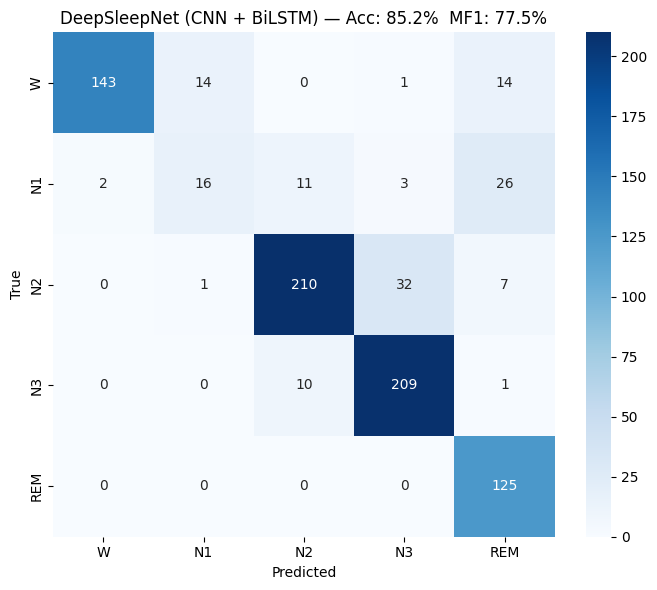

Model saved.


In [ ]:
full_model.eval()
with torch.no_grad():
    test_out  = full_model(X_test_seq_tensor)
    test_pred = test_out.argmax(-1).view(-1).numpy()
    test_true = y_test_seq_tensor.view(-1).numpy()

acc  = 100 * (test_pred == test_true).mean()
mf1  = f1_score(test_true, test_pred, average='macro') * 100

print(f"Final Test Accuracy : {acc:.1f}%")
print(f"Final Macro F1      : {mf1:.1f}%")
print()
print(classification_report(test_true, test_pred, target_names=stage_names))

# Confusion matrix
cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"DeepSleepNet (CNN + BiLSTM) — Acc: {acc:.1f}%  MF1: {mf1:.1f}%")
plt.tight_layout()
plt.show()

# Save final model
torch.save(full_model.state_dict(), "deepsleepnet_finetuned.pth")
print("Model saved.")